**Olist E-commerce financial analysis project**

In [3]:
#Importing the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None)

In [5]:
#Loading the Datasets

orders = pd.read_csv('olist_orders_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')

In [8]:
# exploring the datasets header

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [10]:
# exploring the dataset summary

orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [11]:
# checking for the Null values

orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [14]:
###Merging the Datasets###

#1) orders and payments

df = pd.merge(orders, payments, on='order_id', how='left')

#2) order and Items

df = pd.merge(df, order_items, on='order_id', how='left')

#3) customer and orders

df = pd.merge(df, customers, on='customer_id', how='left')

In [18]:
### DATA CLEANING ###

# 1_ convert dates

df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# 2_ Creating month column for reporting

df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')



In [19]:
# 3_ Checking the missing Values

df.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,176
order_delivered_carrier_date,2074
order_delivered_customer_date,3397
order_estimated_delivery_date,0
payment_sequential,3
payment_type,3


In [ ]:
###Creating the Financial columns###

In [20]:
#Revenue (payment Value)

df['revenue'] = df['payment_value']

In [21]:
# cost(Freight)

df['cost'] = df['freight_value']

In [29]:
# Profit

df['Profit'] = (df['revenue'] - df['cost']).round(2)

In [30]:
### MONTHLY FINANCIAL STATEMENT OR SUMMARY (MINI P&L)###

monthly_pnl = df.groupby('order_month').agg({
    'revenue': 'sum',
    'cost': 'sum',
    'profit': 'sum'
}).reset_index()

monthly_pnl

,order_month,revenue,cost,profit
0,2016-09,388.47,87.39,268.62
1,2016-10,76120.17,7607.80,66306.78
2,2016-12,19.62,8.72,10.90
3,2017-01,189015.66,17817.55,169961.86
4,2017-02,349701.93,41476.51,302658.28
5,2017-03,544738.23,61331.25,465630.41
6,2017-04,510891.55,56958.36,448707.17
7,2017-05,731017.09,84749.23,639755.32
8,2017-06,608891.38,73464.50,527288.77
9,2017-07,744599.53,93695.97,643597.11


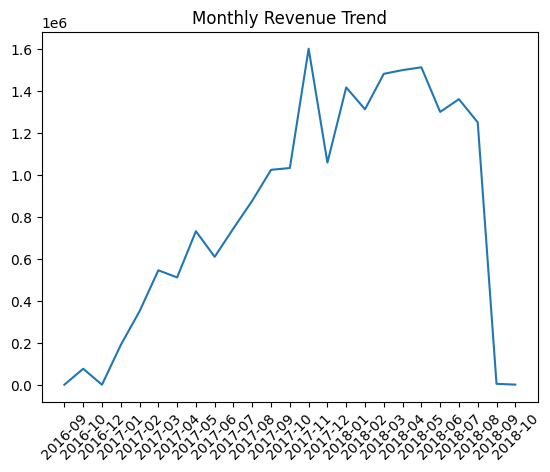

In [32]:
##Visualizing Revenue trend

monthly_pnl['order_month'] = monthly_pnl['order_month'].astype(str)

plt.figure()
plt.plot(monthly_pnl['order_month'], monthly_pnl['revenue'])
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend')


plt.show()

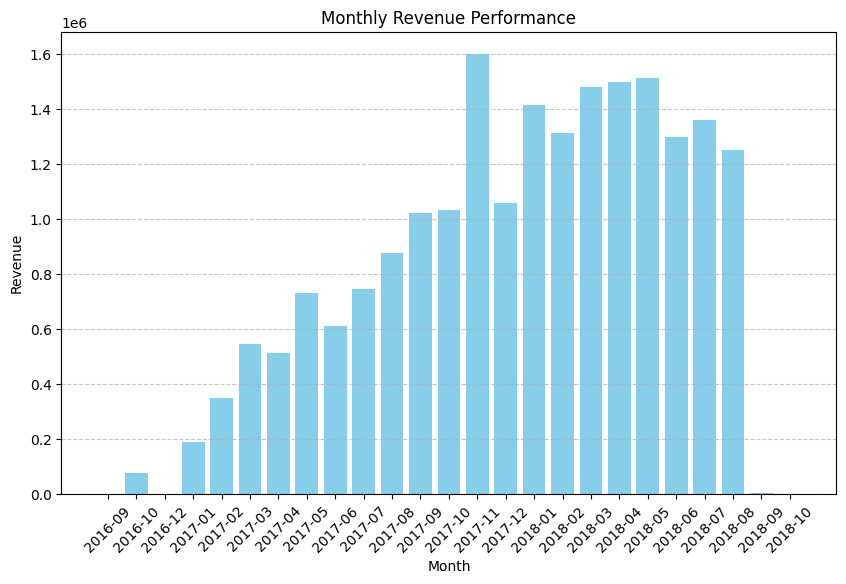

In [34]:
##Visualizing Revenue trend wih Bar Graph

plt.figure(figsize=(10, 6))
plt.bar(monthly_pnl['order_month'], monthly_pnl['revenue'], color='skyblue')
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.title('Monthly Revenue Performance')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()